# Modelo 2 — seleção do grupo de controle

**O que ele resolve.** O estudo de impacto afirma que o entorno de um data center converteu
mais. Mais **que o quê**? Sem um terreno de comparação, o número não significa nada — a região
inteira podia estar urbanizando.

Este modelo escolhe, para cada data center, **um terreno equivalente que não recebeu obra**.
Tudo que o estudo afirma é a diferença entre os dois.

> Se este modelo escolher mal, todo o resto do trabalho desaba junto. É a peça mais
> silenciosa e uma das mais críticas.

In [1]:
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DADOS = RAIZ / "modelo-impacto" / "raw" / "controles-rf"

cand = pd.read_csv(DADOS / "candidatos_avaliados_rf.csv")
par  = pd.read_csv(DADOS / "pareamento_controle_rf.csv")
print(f"{cand.site_id.nunique()} campi · {len(cand)} finalistas avaliados · {len(par)} pares fechados")

15 campi · 71 finalistas avaliados · 15 pares fechados


## 1. De onde saem os candidatos

Não é busca livre. Para cada data center, uma **grade determinística**:

| | |
|---|---|
| raios | 15, 19, 23, 27, 31, 35, 40 km |
| azimutes | 24 (de 15 em 15 graus) |
| **candidatos por campus** | **168** |

O anel de 15–40 km é uma decisão de desenho com dois lados. **Perto demais** e o controle cai
dentro da própria área de influência do data center — deixaria de ser controle. **Longe demais**
e ele deixa de compartilhar o contexto regional: clima, relevo, dinâmica econômica, pressão
urbana. O anel é o compromisso.

## 2. Os filtros — o que elimina um candidato

Aplicados em ordem, do mais barato ao mais caro:

**Geométricos** (grátis, eliminam a maioria)
- não pode sobrepor o buffer de 5 km do próprio data center
- não pode cair perto de **outro** data center conhecido — um controle contaminado é pior que
  nenhum controle
- não pode cair em água ou fora da área com imagem

**Administrativo** (rede — Nominatim + IBGE)
- mesmo município, ou município vizinho da **mesma microrregião do IBGE**

Este último existe para controlar confundidor não observável: dois pontos no mesmo município
compartilham prefeitura, plano diretor, zoneamento e ciclo econômico. É a variável que não dá
para medir por satélite e que mais explicaria crescimento diferente.

## 3. O funil em dois estágios, e por que ele existe

Aqui está a decisão de engenharia que define o modelo.

O critério **certo** de semelhança é a saída do nosso próprio classificador: dois terrenos são
parecidos se o modelo vê as mesmas classes neles. Mas isso custa caro — cada candidato exige
baixar 6 bandas, calcular 7 índices e rodar o RF: **~23 s por ponto-ano**. Com ~20 candidatos
válidos por campus × 15 campi, seriam ~300 pontos e quase **2 horas** de rede encadeada.

A solução é um funil:

| estágio | critério | custo | o que decide |
|---|---|---|---|
| 1 | distância L1 da distribuição de classes do **MapBiomas** | grátis (consulta server-side) | quem entra na final |
| 2 | distância L1 da saída do **`rf_v1.0-tuned`** | ~23 s/ponto | **o vencedor** |

Só os **5 melhores** do estágio 1 passam pelo estágio 2.

**O custo dessa escolha, declarado:** se o melhor candidato pelo RF estivesse fora do top-5 do
MapBiomas, ele nunca seria avaliado. As duas medidas são correlacionadas — medem a mesma
cobertura, no mesmo buffer, no mesmo ano — mas não são a mesma coisa. Por isso o CSV publica
**os dois L1 lado a lado** de todos os finalistas: dá para conferir o quanto os critérios
concordam, em vez de confiar que concordam.

Em 12 de 15 campi, MapBiomas e RF elegeriam o MESMO controle.
Nos outros 3, o pré-ranqueamento teria escolhido diferente —
é exatamente por isso que a decisão final é do RF.


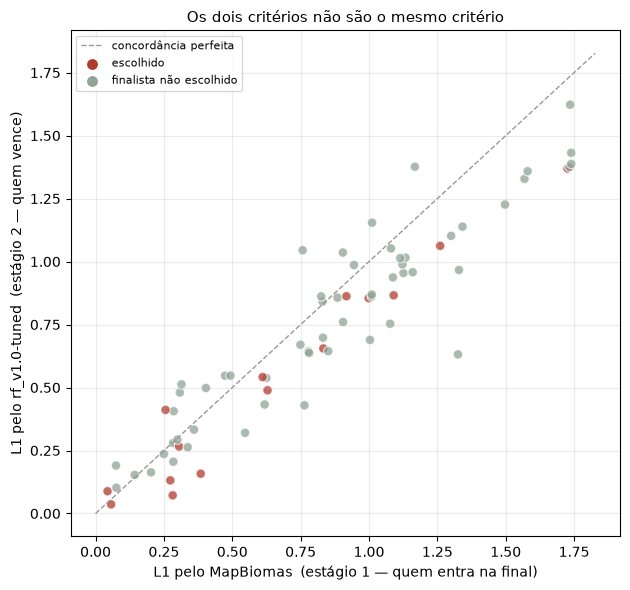

In [2]:
concordancia = cand.groupby("site_id").apply(
    lambda g: g.sort_values("l1_mapbiomas").iloc[0]["site_id_controle"]
              == g.sort_values("l1_rf").iloc[0]["site_id_controle"],
    include_groups=False,
)
n_igual = int(concordancia.sum())
print(f"Em {n_igual} de {len(concordancia)} campi, MapBiomas e RF elegeriam o MESMO controle.")
print(f"Nos outros {len(concordancia) - n_igual}, o pré-ranqueamento teria escolhido diferente —")
print("é exatamente por isso que a decisão final é do RF.")

fig, ax = plt.subplots(figsize=(6.4, 6))
ax.scatter(cand.l1_mapbiomas, cand.l1_rf, s=46, alpha=.75,
           c=np.where(cand.escolhido, "#B03A2E", "#8FA396"),
           edgecolors="white", linewidths=.8)
lim = [0, max(cand.l1_mapbiomas.max(), cand.l1_rf.max()) * 1.05]
ax.plot(lim, lim, ls="--", c="#999", lw=1, label="concordância perfeita")
ax.set_xlabel("L1 pelo MapBiomas  (estágio 1 — quem entra na final)")
ax.set_ylabel("L1 pelo rf_v1.0-tuned  (estágio 2 — quem vence)")
ax.set_title("Os dois critérios não são o mesmo critério", fontsize=11)
ax.scatter([], [], c="#B03A2E", label="escolhido", s=46)
ax.scatter([], [], c="#8FA396", label="finalista não escolhido", s=46)
ax.legend(fontsize=8); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

## 4. A escala de qualidade, e o que ela admite

O L1 varia de 0 (distribuições idênticas) a 2 (sem sobreposição nenhuma).

| selo | L1 |
|---|---|
| `bom` | ≤ 0,10 |
| `aceitavel` | ≤ 0,20 |
| `ruim` | > 0,20 |

In [3]:
q = par.qualidade.value_counts().reindex(["bom", "aceitavel", "ruim"]).fillna(0).astype(int)
print(q.to_string())
print(f"\nL1 mediano dos pares fechados: {par.l1_rf.median():.3f}")

qualidade
bom           3
aceitavel     2
ruim         10

L1 mediano dos pares fechados: 0.489


**A maioria dos pares é `ruim`, e isso está reportado, não escondido.**

O motivo é estrutural: data center brasileiro fica em tecido urbano heterogêneo — a
caracterização de 612 campi (notebook 05) mostra que o entorno mediano é **85,5% construído**.
Achar um terreno a 15–40 km com a mesma composição é difícil por natureza.

O que sustenta o estudo apesar disso não é a qualidade do pareamento individual — é o
**placebo**: a mesma estatística, aplicada a 15 pares controle-contra-controle, dá 8/15
(p=0,50). Se pares `ruim` fabricassem sinal, o placebo teria achado algo. Não achou.

## O que este modelo NÃO faz

- **Não afirma que o controle é idêntico.** Afirma que é o mais parecido que a grade encontrou,
  e publica o quanto ele é parecido.
- **Não controla o que não é visível por satélite** além do filtro de município — incentivo
  fiscal, chegada de rodovia, loteamento aprovado.
- **Não garante sucesso.** Na expansão da amostra, 4 de 10 campi ficaram `sem_candidato`:
  sítios urbanos densos onde o anel de 15–40 km cai em outro município ou perto de outro data
  center. Falhar é o filtro funcionando.